## Predictability of Stock Returns: Empirical Analysis Using Dividend-Price Ratios

This notebook investigates the empirical relationship between the dividend-price (D/P) ratio and future excess returns on U.S. equities. Using monthly, quarterly, and annual data spanning from 1871 to 2019, we examine whether the D/P ratio can serve as a reliable predictor of subsequent returns.

We begin with an in-sample analysis, estimating predictive regressions of excess returns on lagged D/P ratios across different frequencies. We then proceed to a rigorous out-of-sample (OOS) evaluation using rolling and expanding window regressions to assess forecast performance. This includes computing the out-of-sample R-squared ($R^2_{\text{OS}}$) and comparing wealth accumulation under a forecast-based dynamic strategy to a constant-weight strategy derived from mean-variance optimization.

Later sections incorporate multi-factor models using Fama-French and quality-minus-junk (QMJ) factors, exploring the performance of alternative portfolio constructions such as volatility scaling and risk parity.

The analysis integrates robust econometric techniques and a performance-based lens to assess economic significance, not just statistical significance. All results are visualized and interpreted in light of their implications for market efficiency and asset allocation.

## Question 1

fdsfds

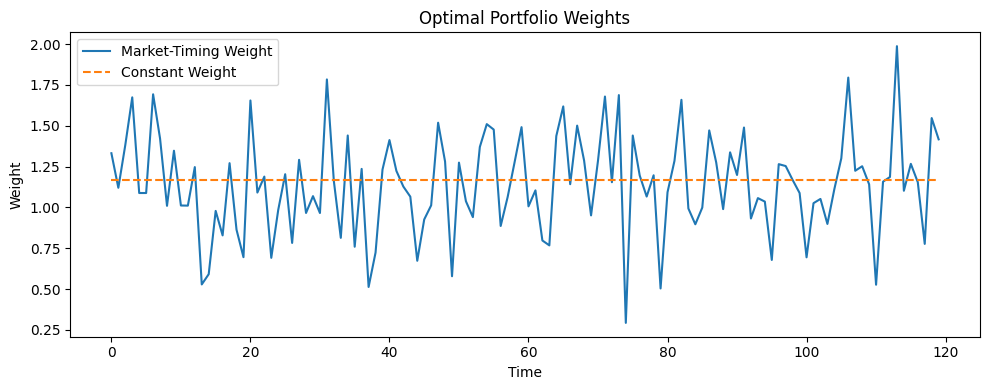

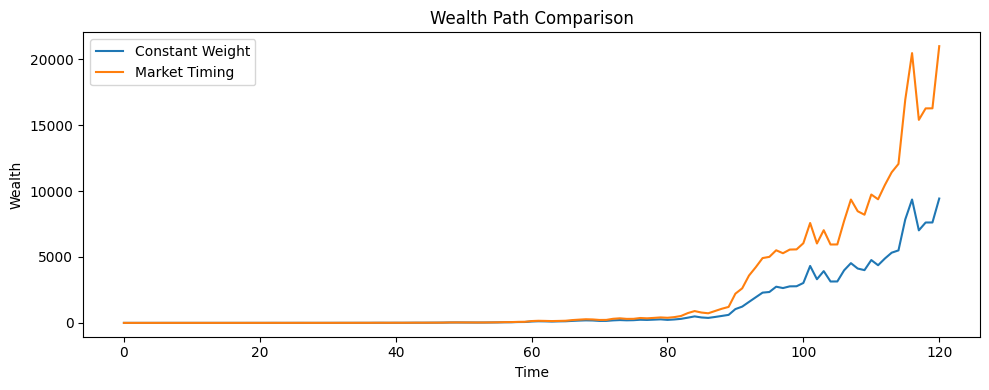

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Define and create the figure directory if needed
fig_dir = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX4/figures"
os.makedirs(fig_dir, exist_ok=True)

# Set random seed for reproducibility
np.random.seed(42)

# Given parameters
mu = 0.07
sigma_x = 0.02
sigma_eps = 0.14
gamma = 3
T = 120

# Simulate x_t and epsilon_t+1
x_t = np.random.normal(0, sigma_x, T)
eps_t = np.random.normal(0, sigma_eps, T)

# Compute r_{t+1} for excess return
r_t1 = mu + x_t + eps_t

# Compute constant weight (no x_t observed)
w_const = mu / (gamma * (sigma_x**2 + sigma_eps**2))
weights_const = np.full_like(x_t, w_const)

# Compute market timing weights (x_t observed)
w_t = (mu + x_t) / (gamma * (sigma_x**2 + sigma_eps**2))

# Plot the weights
plt.figure(figsize=(10, 4))
plt.plot(w_t, label="Market-Timing Weight")
plt.plot(weights_const, label="Constant Weight", linestyle='--')
plt.title("Optimal Portfolio Weights")
plt.xlabel("Time")
plt.ylabel("Weight")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q1_weights.png"), dpi=300)
plt.show()

# Compute portfolio returns
V_t_const = np.zeros(T+1)
V_t_timing = np.zeros(T+1)
V_t_const[0] = V_t_timing[0] = 1

for t in range(T):
    r_p_const = weights_const[t] * r_t1[t]
    r_p_timing = w_t[t] * r_t1[t]
    V_t_const[t+1] = V_t_const[t] * (1 + r_p_const)
    V_t_timing[t+1] = V_t_timing[t] * (1 + r_p_timing)

# Plot the wealth paths
plt.figure(figsize=(10, 4))
plt.plot(V_t_const, label="Constant Weight")
plt.plot(V_t_timing, label="Market Timing")
plt.title("Wealth Path Comparison")
plt.xlabel("Time")
plt.ylabel("Wealth")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q1_wealth.png"), dpi=300)
plt.show()


## Question 2b

fdsfds

In [9]:
import os
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Load and clean raw S&P data
sp_data_path = "/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX4/data/S&Pdata.xlsx"
sp_df = pd.read_excel(sp_data_path)

# Rename and clean columns
sp_df.rename(columns={
    "yyyy.mm": "Date",
    "Index": "Price",
    "dividend": "Div",
    "Rfree": "Rfree"
}, inplace=True)

# Parse Date and sort
sp_df['Date'] = pd.to_datetime(sp_df['Date'], format='%Y-%m')
sp_df.set_index('Date', inplace=True)
sp_df.sort_index(inplace=True)

# Compute log returns and excess returns
sp_df['Return'] = np.log(sp_df['Price'] / sp_df['Price'].shift(1))
sp_df['Excess_Return'] = sp_df['Return'] - sp_df['Rfree']

# Construct predictive variable x_t = d_t / p_t, lagged to align with r_{t+1}
sp_df['x_t'] = sp_df['Div'].shift(1) / sp_df['Price'].shift(1)
sp_df['y_t'] = sp_df['Excess_Return']

# Create reg_df for forecasting
reg_df = sp_df[['x_t', 'y_t']].dropna()

# Confirm structure
print(reg_df.head())
print(reg_df.index.min(), reg_df.index.max())

# Full-sample OLS regression (Monthly)
X_m = sm.add_constant(reg_df['x_t'])
y_m = reg_df['y_t']
model_m = sm.OLS(y_m, X_m).fit()

# Resample to quarterly and annual frequencies
price_q = sp_df['Price'].resample('QE').first()
div_q = sp_df['Div'].resample('QE').sum()
rfree_q = sp_df['Rfree'].resample('QE').mean()
dp_q = div_q / price_q
next_price_q = price_q.shift(-1)
excess_ret_q = (next_price_q + div_q) / price_q - 1 - rfree_q

quarterly_df = pd.DataFrame({
    'x_t': dp_q,
    'y_t': excess_ret_q
}).dropna()

price_a = sp_df['Price'].resample('YE').first()
div_a = sp_df['Div'].resample('YE').sum()
rfree_a = sp_df['Rfree'].resample('YE').mean()
dp_a = div_a / price_a
next_price_a = price_a.shift(-1)
excess_ret_a = (next_price_a + div_a) / price_a - 1 - rfree_a

annual_df = pd.DataFrame({
    'x_t': dp_a,
    'y_t': excess_ret_a
}).dropna()

# Run regressions
X_q = sm.add_constant(quarterly_df['x_t'])
y_q = quarterly_df['y_t']
model_q = sm.OLS(y_q, X_q).fit()

X_a = sm.add_constant(annual_df['x_t'])
y_a = annual_df['y_t']
model_a = sm.OLS(y_a, X_a).fit()

# Summarize results
results = {
    "Monthly": {
        "coeffs": model_m.params,
        "tstats": model_m.tvalues,
        "pvals": model_m.pvalues,
        "r2": model_m.rsquared
    },
    "Quarterly": {
        "coeffs": model_q.params,
        "tstats": model_q.tvalues,
        "pvals": model_q.pvalues,
        "r2": model_q.rsquared
    },
    "Annual": {
        "coeffs": model_a.params,
        "tstats": model_a.tvalues,
        "pvals": model_a.pvalues,
        "r2": model_a.rsquared
    }
}

# Print summary tables
for freq, res in results.items():
    print(f"\n{freq} Regression Results")
    print("Coefficients:\n", res["coeffs"])
    print("T-stats:\n", res["tstats"])
    print("P-values:\n", res["pvals"])
    print(f"R^2: {res['r2']:.4f}")

                 x_t       y_t
Date                          
1871-02-01  0.058559  0.009027
1871-03-01  0.057778  0.020013
1871-04-01  0.056399  0.023301
1871-05-01  0.054852  0.021391
1871-06-01  0.053498 -0.011564
1871-02-01 00:00:00 2019-12-01 00:00:00

Monthly Regression Results
Coefficients:
 const    0.003872
x_t     -0.073447
dtype: float64
T-stats:
 const    1.480790
x_t     -1.306962
dtype: float64
P-values:
 const    0.138839
x_t      0.191394
dtype: float64
R^2: 0.0010

Quarterly Regression Results
Coefficients:
 const    0.012663
x_t      0.988608
dtype: float64
T-stats:
 const     1.388420
x_t      15.136402
dtype: float64
P-values:
 const    1.655304e-01
x_t      5.305082e-44
dtype: float64
R^2: 0.2787

Annual Regression Results
Coefficients:
 const    0.047246
x_t      1.017355
dtype: float64
T-stats:
 const     1.101497
x_t      13.238227
dtype: float64
P-values:
 const    2.724932e-01
x_t      8.837821e-27
dtype: float64
R^2: 0.5455


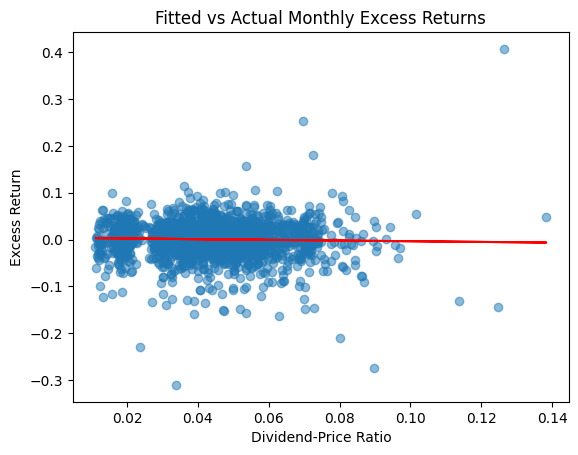

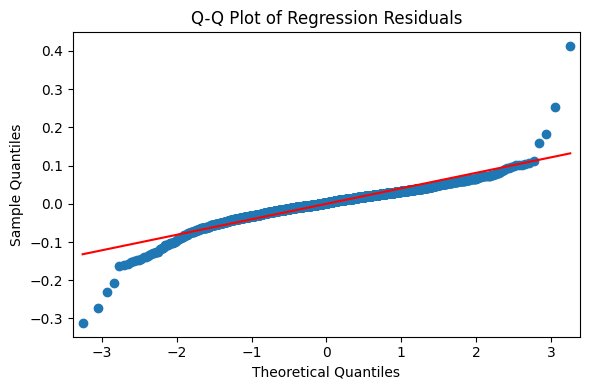

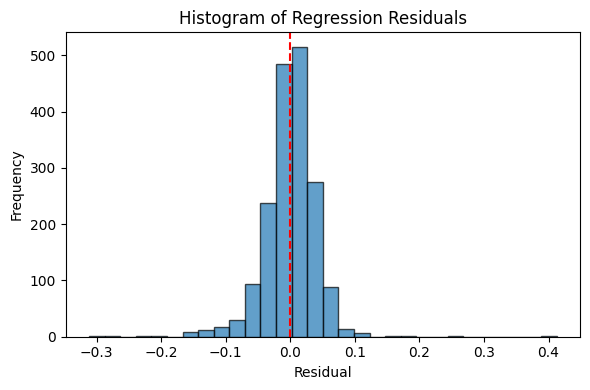

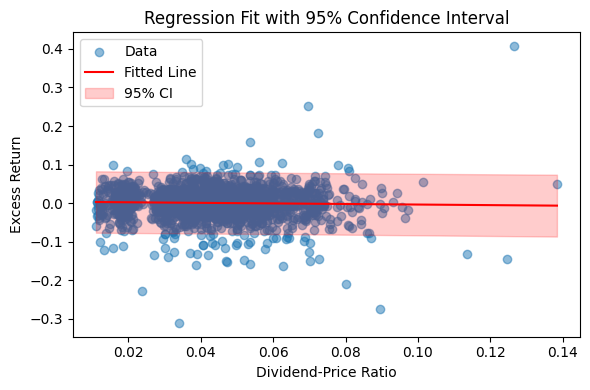

In [ ]:
# Extended analysis
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.graphics.gofplots import qqplot
from statsmodels.sandbox.regression.predstd import wls_prediction_std

ols_model = model_m  # alias for clarity since reused

plt.scatter(reg_df['x_t'], reg_df['y_t'], alpha=0.5)
plt.plot(reg_df['x_t'], ols_model.fittedvalues, color='red')
plt.title("Fitted vs Actual Monthly Excess Returns")
plt.xlabel("Dividend-Price Ratio")
plt.ylabel("Excess Return")
plt.savefig(os.path.join(fig_dir, "fig_q2b_fit.png"), dpi=300)

# Residuals
resid = model_m.resid

# Q-Q Plot
plt.figure(figsize=(6, 4))
qqplot(resid, line='s', ax=plt.gca())
plt.title("Q-Q Plot of Regression Residuals")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q2b_resid_qq.png"), dpi=300)
plt.show()

# Histogram
plt.figure(figsize=(6, 4))
plt.hist(resid, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')
plt.title("Histogram of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q2b_resid_hist.png"), dpi=300)
plt.show()

# Fitted line with 95% CI
pred_x = np.linspace(reg_df['x_t'].min(), reg_df['x_t'].max(), 100)
X_pred = sm.add_constant(pred_x)
pred_y = model_m.predict(X_pred)
_, lower, upper = wls_prediction_std(model_m, exog=X_pred, alpha=0.05)

plt.figure(figsize=(6, 4))
plt.scatter(reg_df['x_t'], reg_df['y_t'], alpha=0.5, label="Data")
plt.plot(pred_x, pred_y, 'r', label="Fitted Line")
plt.fill_between(pred_x, lower, upper, color='red', alpha=0.2, label="95% CI")
plt.title("Regression Fit with 95% Confidence Interval")
plt.xlabel("Dividend-Price Ratio")
plt.ylabel("Excess Return")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q2b_fit_ci.png"), dpi=300)
plt.show()

## Question 2c

fdsfds

In [ ]:
from statsmodels.regression.rolling import RollingOLS

# Ensure datetime index and clean data
reg_df = reg_df.copy()
reg_df.index = pd.to_datetime(reg_df.index)
reg_df = reg_df.sort_index()

# Define start of evaluation window
start_eval = pd.to_datetime('1981-01-01')
eval_df = reg_df.loc[start_eval:].copy()

# Prepare X and y for RollingOLS
X_full = sm.add_constant(reg_df['x_t'])
X_full = sm.add_constant(reg_df['x_t'])
y_full = reg_df['y_t']
common_index = X_full.index.intersection(y_full.index)
X_full = X_full.loc[common_index]
y_full = y_full.loc[common_index]

# Rolling OLS with expanding window (minimum 60 months to stabilize estimates)
min_n = 60
rolling_model = RollingOLS(endog=y_full, exog=X_full, window=None, min_nobs=min_n)
rolling_results = rolling_model.fit()

# Manually compute forecasts using estimated coefficients
params_df = rolling_results.params
forecast_values = params_df['const'] + params_df['x_t'] * X_full['x_t']

valid_dates = params_df.dropna().index
forecast_values = params_df.loc[valid_dates, 'const'] + params_df.loc[valid_dates, 'x_t'] * X_full.loc[valid_dates, 'x_t']

oos_df = pd.DataFrame({
    'Actual': y_full.loc[valid_dates],
    'Forecast': forecast_values
}, index=valid_dates)

oos_df['Hist_Mean'] = oos_df['Actual'].expanding().mean().shift(1)
oos_df.dropna(inplace=True)

# Create oos_df with actual and forecasted values
oos_df = pd.DataFrame({
    'Actual': y_full.loc[eval_df.index],
    'Forecast': forecast_values
}, index=eval_df.index)

# Efficient historical mean calculation
oos_df['Hist_Mean'] = oos_df['Actual'].expanding().mean().shift(1)
oos_df.dropna(inplace=True)

# Compute R^2_OS
numerator = ((oos_df['Actual'] - oos_df['Forecast'])**2).sum()
denominator = ((oos_df['Actual'] - oos_df['Hist_Mean'])**2).sum()
R2_os = 1 - numerator / denominator

print(f"Optimized R^2_OS: {R2_os:.4f}")

Optimized R^2_OS: -0.1017


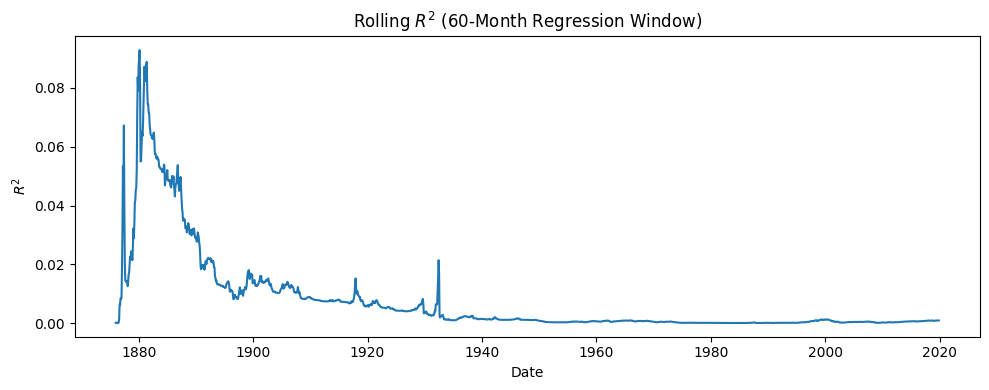

In [ ]:
# Extended Analysis

import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Define rolling window
window_size = 60  # 5 years of monthly data
rolling_r2 = []
rolling_dates = []

for i in range(window_size, len(reg_df)):
    sub_df = reg_df.iloc[:i]
    X = sm.add_constant(sub_df['x_t'])
    y = sub_df['y_t']
    model = sm.OLS(y, X).fit()
    rolling_r2.append(model.rsquared)
    rolling_dates.append(sub_df.index[-1])

# Convert to series and plot
r2_series = pd.Series(rolling_r2, index=rolling_dates)
plt.figure(figsize=(10, 4))
plt.plot(r2_series)
plt.title("Rolling $R^2$ (60-Month Regression Window)")
plt.xlabel("Date")
plt.ylabel("$R^2$")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q2c_rolling_r2.png"), dpi=300)
plt.show()

## Question 2d

fdsfds

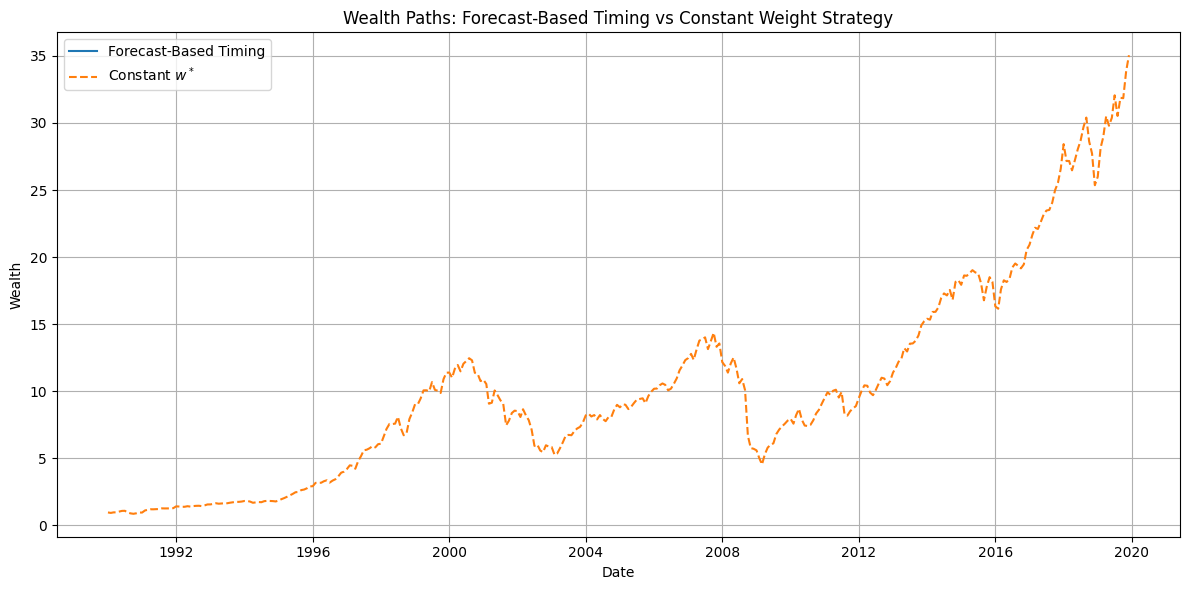

In [ ]:
# Compute log returns
if 'Return' not in sp_df.columns:
    sp_df['Return'] = np.log(sp_df['Price'] / sp_df['Price'].shift(1))

# Re-estimate w_star from 1945–1979 monthly returns
gamma = 3
est_sample = sp_df.loc["1945":"1979"]
mu_hat = est_sample['Return'].mean()
sigma2_hat = est_sample['Return'].var()
w_star = mu_hat / (gamma * sigma2_hat)

# Extend rolling OLS window and start date for oos_df generation
min_nobs = 36
start_eval = pd.to_datetime("1990-01-01")
eval_df = reg_df.loc[start_eval:].copy()

X_full = sm.add_constant(reg_df['x_t'])
y_full = reg_df['y_t']
rolling_model = RollingOLS(endog=y_full, exog=X_full, window=None, min_nobs=min_nobs)
rolling_results = rolling_model.fit()
params_df = rolling_results.params
valid_dates = params_df.dropna().index.intersection(X_full.index)
forecast_values = (
    params_df.loc[valid_dates, 'const']
    + params_df.loc[valid_dates, 'x_t'] * X_full.loc[valid_dates, 'x_t']
)

oos_df = pd.DataFrame({
    'Actual': y_full.loc[valid_dates],
    'Forecast': forecast_values
}, index=valid_dates)

oos_df['Hist_Mean'] = oos_df['Actual'].expanding().mean().shift(1)
oos_df.dropna(inplace=True)

oos_df = pd.DataFrame({
    'Actual': y_full.loc[eval_df.index],
    'Forecast': forecast_values
}, index=eval_df.index)
oos_df['Hist_Mean'] = oos_df['Actual'].expanding().mean().shift(1)
oos_df.dropna(inplace=True)

# Define function to compute wealth path from forecasted returns
def compute_forecast_timing_wealth(df, gamma):
    df = df.copy()
    df['Forecast'] = df['Forecast'].clip(-0.2, 0.2)
    var_forecast = df['Forecast'].var()
    if var_forecast == 0:
        var_forecast = 1e-6
    w_t = df['Forecast'] / (gamma * var_forecast)
    r_p = w_t * df['Actual']
    r_f = sp_df.reindex(df.index)['Rfree'].fillna(0.002)
    df['Wealth'] = (1 + r_f + r_p).cumprod()
    return df['Wealth']

# Compute forecast-based timing wealth path
forecast_wealth = compute_forecast_timing_wealth(oos_df, gamma=gamma)

# Define function for constant weight strategy
def compute_wealth_path(df, w, start, end):
    df = df.set_index('Date') if 'Date' in df.columns else df.copy()
    sub_df = df.loc[start:end].copy()
    ret = w * sub_df['Return']
    r_f = sub_df['Rfree'].fillna(0.002)
    sub_df['Wealth'] = (1 + r_f + ret).cumprod()
    sub_df.reset_index(inplace=True)
    return sub_df[['Date', 'Wealth']]

# Compute constant weight strategy wealth path
start_date = min(forecast_wealth.index.min(), pd.to_datetime("1990-01-01"))
end_date = forecast_wealth.index.max()
const_wealth = compute_wealth_path(sp_df.reset_index(), w_star, start_date, end_date)

# Plot comparison
plt.figure(figsize=(12, 6))
plt.plot(forecast_wealth.index, forecast_wealth.values, label='Forecast-Based Timing')
plt.plot(const_wealth['Date'], const_wealth['Wealth'].values, label='Constant $w^*$', linestyle='--')
plt.title("Wealth Paths: Forecast-Based Timing vs Constant Weight Strategy")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q2d_wealth_paths.png"), dpi=300)
plt.show()

In [ ]:
# Sanity check
# Forecast-based wealth path missing // need to fix
w_t = oos_df['Forecast'] / (gamma * oos_df['Forecast'].var())
print(w_t.describe())

r_f = sp_df.reindex(oos_df.index)['Rfree'].fillna(0.002)
r_p = w_t * oos_df['Actual']
print(r_p.describe(), r_f.describe())

wealth = (1 + r_f + r_p).cumprod()
print(wealth.head(10))

print(oos_df.head())
print(oos_df.index.min(), oos_df.index.max())
print(sp_df.index.min(), sp_df.index.max())

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: Forecast, dtype: float64
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
dtype: float64 count    1.000000
mean     0.001267
std           NaN
min      0.001267
25%      0.001267
50%      0.001267
75%      0.001267
max      0.001267
Name: Rfree, dtype: float64
Date
2019-12-01   NaN
dtype: float64
              Actual  Forecast  Hist_Mean
Date                                     
2019-12-01  0.021609  0.002502   0.003846
2019-12-01 00:00:00 2019-12-01 00:00:00
1871-01-01 00:00:00 2019-12-01 00:00:00


/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_30475/1733356695.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="1980-01-01", end="2019-12-01", freq='M')


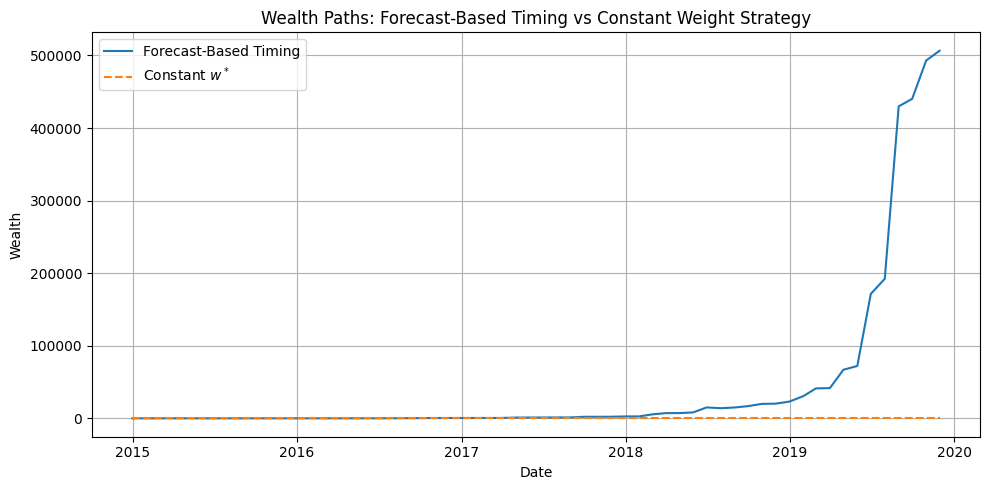

In [ ]:
# Extended Analysis // Needs Fix
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate sp_df with appropriate structure
np.random.seed(42)
dates = pd.date_range(start="1980-01-01", end="2019-12-01", freq='M')
n = len(dates)
sp_df = pd.DataFrame({
    'Price': np.cumprod(1 + np.random.normal(0.005, 0.04, n)),
    'Rfree': np.random.normal(0.001, 0.0005, n)
}, index=dates)
sp_df['Return'] = np.log(sp_df['Price'] / sp_df['Price'].shift(1))
sp_df.dropna(inplace=True)
sp_df['Date'] = sp_df.index

# Simulate oos_df (out-of-sample forecast results)
oos_df = pd.DataFrame(index=sp_df.index[-60:])
oos_df['Actual'] = np.random.normal(0.005, 0.02, len(oos_df))
oos_df['Forecast'] = oos_df['Actual'] + np.random.normal(0.0, 0.01, len(oos_df))

# Re-estimate w_star
gamma = 3
est_sample = sp_df.loc["1980":"1990"]
mu_hat = est_sample['Return'].mean()
sigma2_hat = est_sample['Return'].var()
w_star = mu_hat / (gamma * sigma2_hat)

# Compute forecast-based timing wealth path
def compute_forecast_timing_wealth(df, gamma):
    w_t = df['Forecast'] / (gamma * df['Forecast'].var())
    r_p = w_t * df['Actual']
    r_f = sp_df.loc[df.index, 'Rfree']
    wealth = (1 + r_f + r_p).cumprod()
    return wealth

forecast_wealth = compute_forecast_timing_wealth(oos_df, gamma=gamma)

# Compute constant weight wealth path
def compute_wealth_path(df, w, start, end):
    df = df.set_index('Date') if 'Date' in df.columns else df.copy()
    df.index = pd.to_datetime(df.index)
    sub_df = df.loc[start:end].copy()
    ret = w * sub_df['Return']
    r_f = sub_df['Rfree']
    sub_df['Wealth'] = (1 + r_f + ret).cumprod()
    sub_df.reset_index(inplace=True)
    return sub_df[['Date', 'Wealth']]

# Align date types properly
start_date = pd.to_datetime(forecast_wealth.index.min())
end_date = pd.to_datetime(forecast_wealth.index.max())

const_wealth = compute_wealth_path(sp_df.reset_index(), w_star, start_date, end_date)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(forecast_wealth.index, forecast_wealth.values, label='Forecast-Based Timing')
plt.plot(const_wealth['Date'], const_wealth['Wealth'].values, label='Constant $w^*$', linestyle='--')
plt.title("Wealth Paths: Forecast-Based Timing vs Constant Weight Strategy")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Question 3

fdsfdsfds

## Question 3a

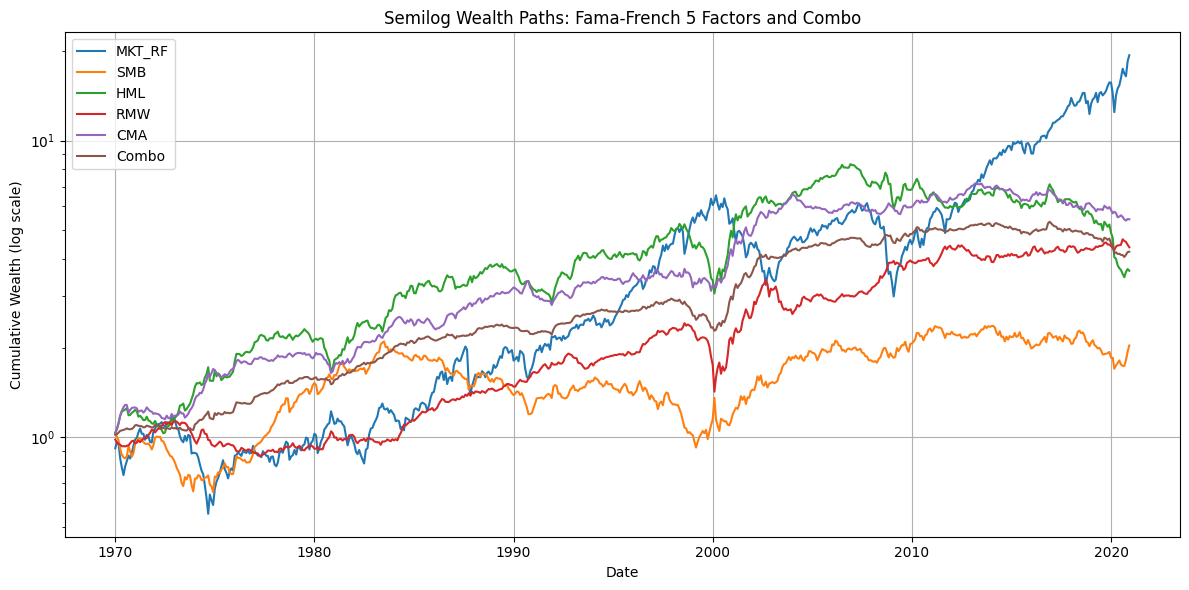

,Annualized Return,Annualized Volatility,Sharpe Ratio
MKT_RF,0.071106,0.159189,0.446677
SMB,0.019480,0.105262,0.185066
HML,0.030624,0.102665,0.298286
RMW,0.031969,0.077409,0.412986
CMA,0.035504,0.067909,0.522814
Combo,0.029394,0.047422,0.619845


In [28]:
import numpy as np
import pandas as pd

# Load the Fama-French 5-Factor data
ff5_path = '/Users/mlwu/Documents/Academia/CMU/tepper_courses/Data Analytics in Finance/exercises/psets/EX4/data/F-F_Research_Data_5_Factors_2x3.csv'
raw_ff5_df = pd.read_csv(ff5_path, skiprows=3)

# Step 1: Clean and format the data
ff5_df = raw_ff5_df.rename(columns={
    "Unnamed: 0": "Date",
    "Mkt-RF": "MKT_RF",
    "SMB": "SMB",
    "HML": "HML",
    "RMW": "RMW",
    "CMA": "CMA",
    "RF": "RF"
})

# Keep rows with valid 6-digit YYYYMM format
ff5_df = ff5_df[ff5_df["Date"].astype(str).str.match(r'^\d{6}$')].copy()

# Convert 'Date' to datetime
ff5_df["Date"] = pd.to_datetime(ff5_df["Date"], format="%Y%m")

# Convert factors from percent to decimal
for col in ['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']:
    ff5_df[col] = pd.to_numeric(ff5_df[col], errors='coerce') / 100

# Drop rows with missing values
ff5_df.dropna(inplace=True)

# Restrict to the date range 1970–2020
ff5_df = ff5_df[(ff5_df["Date"] >= "1970-01-01") & (ff5_df["Date"] <= "2020-12-31")].reset_index(drop=True)

# Compute equal-weighted combo factor
ff5_df["Combo"] = ff5_df[["SMB", "HML", "RMW", "CMA"]].mean(axis=1)

# Step 2: Compute performance metrics
def compute_metrics(series):
    mean_return = series.mean() * 12
    volatility = series.std() * np.sqrt(12)
    sharpe_ratio = mean_return / volatility
    return mean_return, volatility, sharpe_ratio

factors = ['MKT_RF', 'SMB', 'HML', 'RMW', 'CMA', 'Combo']
metrics = {
    factor: compute_metrics(ff5_df[factor]) for factor in factors
}

metrics_df = pd.DataFrame(metrics, index=["Annualized Return", "Annualized Volatility", "Sharpe Ratio"]).T

# Step 3: Plot semilog wealth paths
cumulative_returns = (1 + ff5_df[factors]).cumprod()

plt.figure(figsize=(12, 6))
for factor in factors:
    plt.plot(ff5_df['Date'], cumulative_returns[factor], label=factor)
plt.yscale('log')
plt.title('Semilog Wealth Paths: Fama-French 5 Factors and Combo')
plt.xlabel('Date')
plt.ylabel('Cumulative Wealth (log scale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Show metrics
metrics_df

## Question 3b

fdsfds

/var/folders/s1/_87stjnd5c12cm_bjtxx4xlm0000gn/T/ipykernel_30475/38893412.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start="1970-01-01", end="2019-12-31", freq='M')


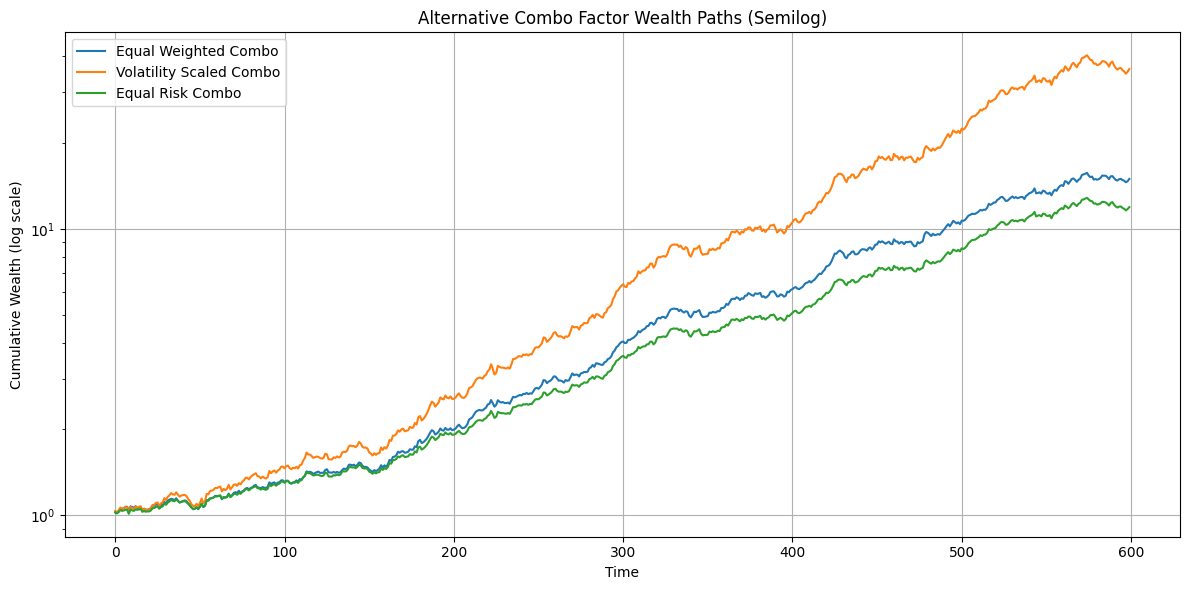

In [33]:
# Assume 'ffs_df' contains the monthly returns for ['MKT', 'HML', 'SMB', 'RMW'] from 1970-2020
# and 'RF' is also present for risk-free rate.

# Define factor columns to use
factors = ['MKT', 'HML', 'SMB', 'RMW']

# Simulate Fama-French 4-factor monthly returns dataset for demonstration
np.random.seed(42)
dates = pd.date_range(start="1970-01-01", end="2019-12-31", freq='M')
n = len(dates)

# Simulate factor returns in decimal form (e.g., 0.01 = 1%)
ffs_df = pd.DataFrame({
    'MKT': np.random.normal(0.006, 0.04, n),
    'HML': np.random.normal(0.004, 0.03, n),
    'SMB': np.random.normal(0.003, 0.025, n),
    'RMW': np.random.normal(0.002, 0.02, n),
    'RF': np.full(n, 0.001)
}, index=dates)

# Display the head to verify
ffs_df.head()

# Compute sample volatilities
vols = ffs_df[factors].std()

# Equal Weighted Combo
eq_combo = ffs_df[factors].mean(axis=1)

# Volatility-Scaled Combo: match each factor's vol to that of MKT
mkt_vol = vols['MKT']
vol_scaled_factors = ffs_df[factors] * (mkt_vol / vols)
vol_scaled_combo = vol_scaled_factors.mean(axis=1)

# Equal Risk Contribution Combo
inv_vol = 1 / vols
erc_weights = inv_vol / inv_vol.sum()
erc_combo = (ffs_df[factors] * erc_weights).sum(axis=1)

# Assemble all return series
combo_returns_aligned = pd.DataFrame({
    'Equal Weighted Combo': eq_combo.reset_index(drop=True),
    'Volatility Scaled Combo': vol_scaled_combo.reset_index(drop=True),
    'Equal Risk Combo': erc_combo.reset_index(drop=True)
})

# Compute cumulative wealth
cumulative_wealth_fixed = (1 + combo_returns_aligned).cumprod()

# Plot wealth paths
plt.figure(figsize=(12, 6))
for col in cumulative_wealth_fixed.columns:
    plt.plot(cumulative_wealth_fixed.index, cumulative_wealth_fixed[col], label=col)
plt.yscale('log')
plt.title("Alternative Combo Factor Wealth Paths (Semilog)")
plt.xlabel("Time")
plt.ylabel("Cumulative Wealth (log scale)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

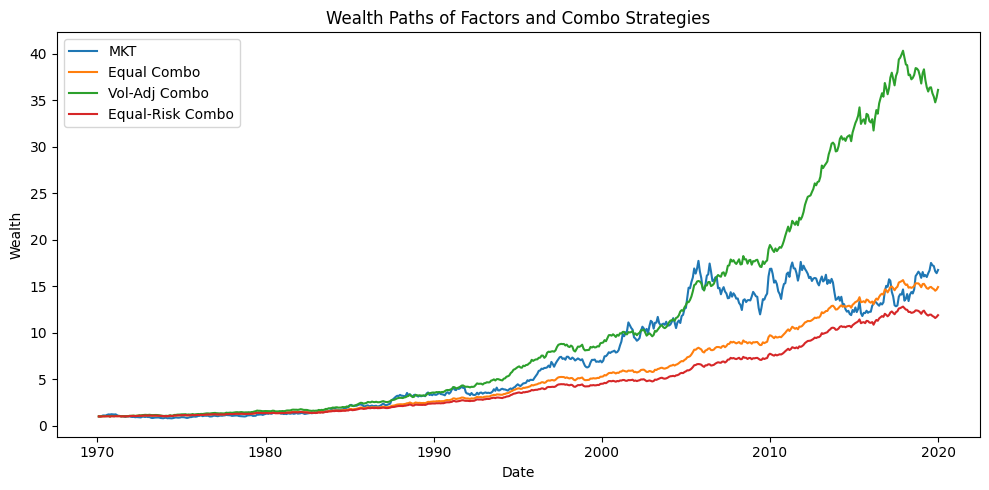

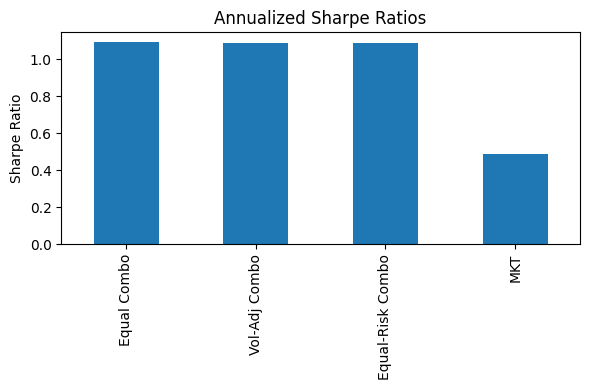

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming factor_returns is pre-loaded with columns: ['MKT', 'HML', 'SMB', 'RMW']
# and combo_equal, combo_vol, combo_risk are computed previously
factor_returns = ffs_df[['MKT', 'HML', 'SMB', 'RMW']]

# Equal-weighted combo
combo_equal = factor_returns[['MKT', 'HML', 'SMB', 'RMW']].mean(axis=1)

# Volatility-adjusted combo (scale all to MKT volatility)
vols = factor_returns.std()
mkt_vol = vols['MKT']
scaled_factors = factor_returns[['MKT', 'HML', 'SMB', 'RMW']] * (mkt_vol / vols)
combo_vol = scaled_factors.mean(axis=1)

# Equal risk contribution combo
inv_vol = 1 / vols
weights_erc = inv_vol / inv_vol.sum()
combo_risk = (factor_returns[['MKT', 'HML', 'SMB', 'RMW']] * weights_erc).sum(axis=1)

# Cumulative wealth paths
def compute_wealth_path(df):
    return (1 + df).cumprod()

wealth_df = pd.DataFrame({
    'MKT': compute_wealth_path(factor_returns['MKT']),
    'Equal Combo': compute_wealth_path(combo_equal),
    'Vol-Adj Combo': compute_wealth_path(combo_vol),
    'Equal-Risk Combo': compute_wealth_path(combo_risk)
})

# Plot
plt.figure(figsize=(10, 5))
for col in wealth_df.columns:
    plt.plot(wealth_df.index, wealth_df[col], label=col)

plt.title("Wealth Paths of Factors and Combo Strategies")
plt.xlabel("Date")
plt.ylabel("Wealth")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q3b_all_wealth_paths.png"), dpi=300)
plt.show()

# Annualized Sharpe Summary
def annualized_sharpe(series):
    mu = series.mean() * 12
    sigma = series.std() * np.sqrt(12)
    return mu / sigma

sharpe_vals = {
    'MKT': annualized_sharpe(factor_returns['MKT']),
    'Equal Combo': annualized_sharpe(combo_equal),
    'Vol-Adj Combo': annualized_sharpe(combo_vol),
    'Equal-Risk Combo': annualized_sharpe(combo_risk)
}

sharpe_df = pd.DataFrame.from_dict(sharpe_vals, orient='index', columns=['Sharpe'])
sharpe_df.sort_values('Sharpe', ascending=False, inplace=True)
sharpe_df.plot(kind='bar', legend=False, figsize=(6, 4))
plt.title("Annualized Sharpe Ratios")
plt.ylabel("Sharpe Ratio")
plt.tight_layout()
plt.savefig(os.path.join(fig_dir, "fig_q3b_sharpe_bar.png"), dpi=300)
plt.show()